In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Directories
data_path="/media/NAS2/ISMIP7/share_with_modellers"

In [102]:
# Load Climatology file

dpath=os.path.join( data_path,"climatology","v3","zhou_annual_06_nov")
outpath=os.path.join( data_path,"parameterisations","meltMIP")
#filename = "OI_Climatology_ismip8km_60m_tf_extrap.nc"
#variable = "tf"
#filename = "OI_Climatology_ismip8km_60m_thetao_extrap.nc"
#variable = 'thetao'
filename = "OI_Climatology_ismip8km_60m_so_extrap.nc"
variable = 'so'


background_file = xr.load_dataset(os.path.join(dpath, filename))


In [103]:
# Create perturbation and safe file

for perturbation in [-200,-100,100,200]:
    print(perturbation)
    perturbed_file = background_file.copy(deep=True)
    
    ds_shifted = (
        background_file[variable].assign_coords(z=background_file.z + perturbation)
        .interp(z=background_file.z, kwargs={"fill_value": None, "bounds_error": False})  # NaNs at edges
    )
    
    # Fill edge NaNs with nearest valid value (forward/backfill along z)
    perturbed_file[variable] = ds_shifted.ffill(dim="z").bfill(dim="z")

    output_file= os.path.join(outpath, f"{Path(filename).stem}_perturbationtc"+str(perturbation)+"m.nc")
    #print((perturbed_file[variable] - background_file[variable]).mean(dim=['x','y','z']))
    ## safe to dataset
    perturbed_file.to_netcdf(output_file)

        

-200
-100
100
200


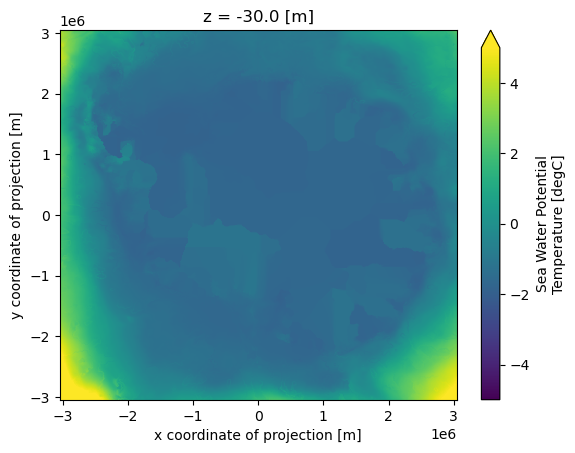

In [93]:
background_file[variable].isel(z=0).plot(vmin=-5,vmax=5)

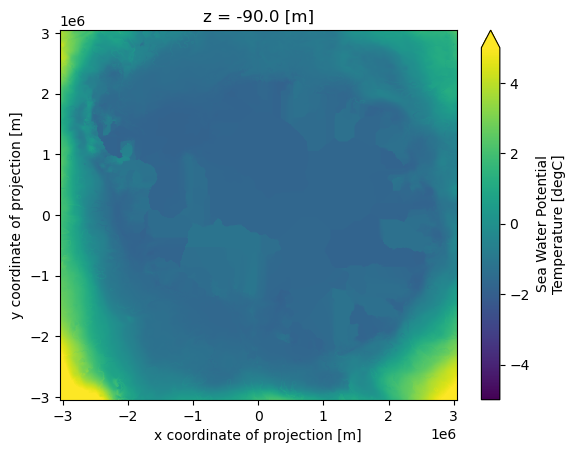

In [97]:
ds_shifted.isel(z=1).plot(vmin=-5, vmax=5)

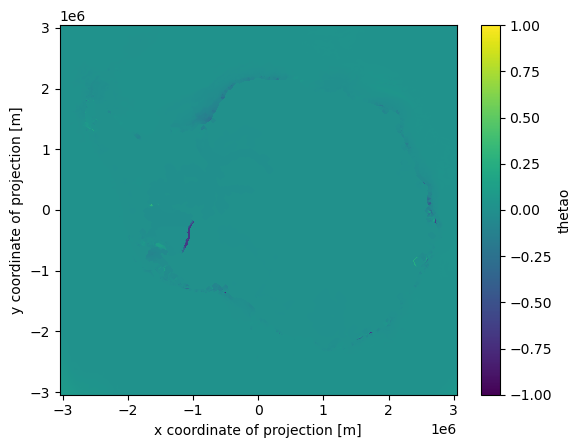

In [83]:
(ds_shifted.isel(z=10) - background_file[variable].isel(z=12)).plot(vmin=-1,vmax=1)